In [1]:
# === Colab 호환 셋업 (자동 추가) ===
import torch as _t
_t._orig_load = getattr(_t, '_orig_load', _t.load)
def _compat_load(*a, **k):
    k.setdefault('weights_only', False)
    return _t._orig_load(*a, **k)
_t.load = _compat_load
try:
    import matplotlib; matplotlib.rcParams['axes.unicode_minus'] = False
except Exception: pass
print('[colab-compat] torch.load weights_only=False 패치 적용')


[colab-compat] torch.load weights_only=False 패치 적용


# 들어가며

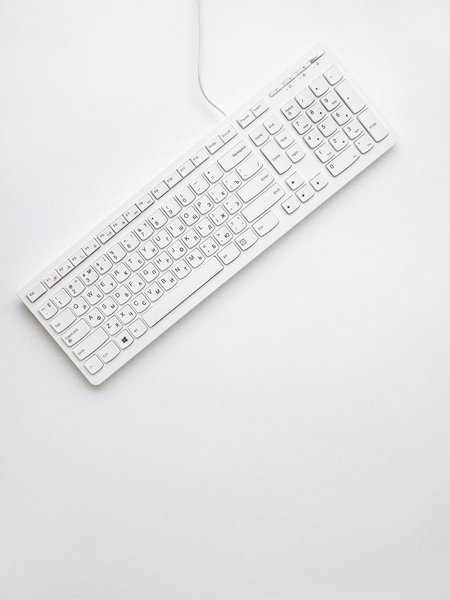

이전 시간에 멋진 **Sequence-to-Sequence** 구조를 배웠습니다. 두 개의 RNN 모듈을 Encoder-Decoder 구조로 결합하여 사용하는 Seq2seq은 그야말로 혁신이었습니다.

Seq2seq이 번역기에 최적화되어 있는 만큼, 이번 코스에선 **Seq2seq 기반 번역기를 직접 만들어보며** 그 구조를 이해해보도록 하겠습니다. 또한 Attention 기법을 추가하여 성능을 높여보기도 할 거고요!

실습에는 영어-스페인어 말뭉치를 사용하지만 직접 하실 프로젝트는 한국어-영어 말뭉치를 사용할 것입니다. 그럼 시작합시다!

**[아이스브레이킹] 지난 시간에 배운 Sequence-to-Sequence에 대해서 간단하게 생각해 볼까요?**

A. Sequence-to-Sequence 모델은 일련의 입력 시퀀스를 다른 일련의 출력 시퀀스로 변환하는 모델입니다.
이 모델은 대부분 자연어 처리에서 사용되며, 예를 들어 기계 번역, 챗봇, 요약, 질의응답 등의 작업에서 널리 사용됩니다.

## 학습 내용
---
2. 데이터 전처리

    필요한 데이터를 준비하고 전처리합니다.

3. 모델 설계

    Bahdanau Attention을 사용해서 코드 실습을 합니다.

4. 훈련하기 (1) Optimizer & Loss

    Encoder-Decoder 구조를 정의합니다.

5. 훈련하기 (2) train_step 구현하기

    Loss를 계산한 후 반환하는 함수를 학습합니다.

6. 훈련하기 (3) 훈련 시작하기

    학습을 진행하고 시각화합니다.

## 학습 목표
---
- 데이터를 필요에 맞게 전처리할 수 있다.
- Encoder-Decoder 구조를 이해할 수 있다.
- Encoder-Decoder 구조를 다른 사람에게 설명할 수 있다.

## 준비물
---
터미널을 열고 프로젝트를 위한 디렉토리를 생성해 주세요.

```
$ mkdir -p ~/aiffel/s2s_translation
```

실습에서는 한국어가 포함된 말뭉치를 사용하므로, 한국어를 잘 시각화하기 위한 준비가 필요합니다. 다만 *`matplotlib` 라이브러리의 기본 폰트는 한국어를 지원하지 않아요!* 올바른 Attention Map을 확인하기 위해 한국어를 지원하는 폰트로 변경해 주도록 합시다.

In [2]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 57 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (40.5 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122579 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


# 데이터 전처리

## 데이터 준비하기
---
먼저 프로젝트에 사용될 라이브러리를 `import` 하도록 합시다.

In [4]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.11.0+cu128


데이터를 다운로드하는 데에는 `urllib.request.urlretrieve()` 함수를 사용할 겁니다. `urllib.request.urlretrieve()`함수는 URL로부터 데이터를 다운받고, `zip_ref.extractall()` 함수는 폴더 내 압축된 파일들을 찾아 해제까지 알아서 할 수 있는 똑똑한 함수랍니다! 아래 소스를 실행해 데이터를 다운로드받아주세요.

In [5]:
dataset_dir = os.path.join(os.path.expanduser("/content/datasets"), "spa-eng")
os.makedirs(dataset_dir, exist_ok=True)
zip_path = os.path.join(dataset_dir, "spa-eng.zip")

if not os.path.exists(zip_path):
    print("데이터 다운로드 중...")
    url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("다운로드 완료!")

data_folder = os.path.join(dataset_dir, "spa-eng")
if not os.path.exists(data_folder):
    print("압축 해제 중...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    print("압축 해제 완료!")

path_to_file = os.path.join(data_folder, "spa.txt")

print("데이터셋 디렉토리:", os.listdir(dataset_dir))

데이터 다운로드 중...
다운로드 완료!
압축 해제 중...
압축 해제 완료!
데이터셋 디렉토리: ['spa-eng', 'spa-eng.zip']


다운로드받은 데이터를 읽어온 후, 형태를 확인해보도록 하죠!

In [6]:
df = pd.read_csv(path_to_file, sep = "\t", names = ["eng", "spa"])
df.head()

,eng,spa
0,Go.,Ve.
1,Go.,Vete.
2,Go.,Vaya.
3,Go.,Váyase.
4,Hi.,Hola.


## 데이터 전처리: 정제하기
---
데이터는 `\t` 기호를 기준으로 영어와 스페인어가 병렬 쌍을 이루고 있습니다. 고로 `\t` **기호를 매개변수로** `split()` **함수를 호출**하면 손쉽게 소스 문장과 타겟 문장을 분리할 수 있겠죠! 추가로 위 예시의 네 번째 문장을 보면 `¡` 같은 요상한 기호가 포함되어 있곤 합니다. 이 같은 특수문자는 **불필요한 노이즈로 작용**할 수 있기 때문에 정**제 과정에서 삭제**하도록 하겠습니다.

> 사실 스페인에서는 역 물음표(¿)와 역 느낌표(¡)를 일반적으로 사용합니다. 문장이 물음표나 느낌표로 끝난다면 해당 문장 맨 앞에 역으로 된 기호를 붙여준다고 해요. 이해를 돕기 위해 이상한 기호 취급을 하였으니 양해를 바랍니다!

정제는 아래 소스를 실행함으로써 진행할 수 있습니다.

In [ ]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    # 스페인어 문자(á é í ó ú ü ñ)는 보존하고, 노이즈 취급하는 역물음표/역느낌표(¿ ¡)만 제거
    sentence = re.sub(r"[^a-záéíóúüñ?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence

print("슝~")

슝~


전처리 과정에서 문장의 시작 문자 `<start>`, 종료 문자 `<end>` 를 붙여주게 됩니다. 이 작업은 Encoder에 들어갈 입력 문장의 전처리에는 굳이 필요하지 않지만, Decoder의 입력 문장과 라벨로 사용할 출력 문장에는 꼭 필요하게 됩니다. 이전 렉처 노드에서 살펴보았듯, Decoder는 첫 입력으로 사용할 시작 토큰과 문장생성 종료를 알리는 끝 토큰이 반드시 필요하기 때문입니다.

원활한 학습을 위해 **데이터는 상위 3만 개만 사용**하도록 하겠습니다.

In [8]:
#df = df[:30000]

df["eng"] = df["eng"].apply(preprocess_sentence)
df["spa"] = df["spa"].apply(lambda x: preprocess_sentence(x))

df.head()

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,váyase .
4,hi .,hola .


## 데이터 전처리: 토큰화
---
`SentencePiece`를 사용하려면 텍스트 파일이 필요합니다. 먼저 `SentencePiece`를 활용해 Tokenizer를 생성하고 테이터를 변환하겠습니다. **변환된 텐서를 80%의 훈련 데이터와 20%의 검증 데이터로 분리하세요!** (Tokenizer의 단어 수는 자유롭게 진행하세요!)

In [9]:
df["eng"].to_csv("eng_corpus.txt", index=False, header=False, encoding="utf-8")
df["spa"].to_csv("spa_corpus.txt", index=False, header=False, encoding="utf-8")

print("파일 저장 완료: eng_corpus.txt, spa_corpus.txt")

파일 저장 완료: eng_corpus.txt, spa_corpus.txt


In [10]:
vocab_size = 3000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

spm.SentencePieceTrainer.train(
    input = "eng_corpus.txt",
    model_prefix = "encoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "spa_corpus.txt",
    model_prefix = "decoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

True

In [11]:
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

True

SentencePiece는 디코딩 과정에서 START_TOKEN과 END_TOKEN을 자동으로 변환해줍니다.

In [12]:
df

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,váyase .
4,hi .,hola .
...,...,...
118959,there are four main causes of alcohol related ...,hay cuatro causas principales de muertes relac...
118960,there are mothers and fathers who will lie awa...,hay madres y padres que se quedan despiertos d...
118961,a carbon footprint is the amount of carbon dio...,una huella de carbono es la cantidad de contam...
118962,since there are usually multiple websites on a...,como suele haber varias páginas web sobre cual...


In [13]:
eng_sample = df["eng"][10000]
spa_sample = df["spa"][10000]
print(eng_sample)
print(spa_sample)

do you like fish ?
te gusta el pescado ?


문장을 인코딩한 뒤 START_TOKEN과 END_TOKEN을 붙여주겠습니다.

In [14]:
enc_token = encoder_tokenizer.encode(eng_sample)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]
enc_token

[1, 23, 8, 48, 612, 11, 2]

위 토큰을 디코딩하면 어떻게 될까요?

In [15]:
enc_decoding = encoder_tokenizer.decode(enc_token)
enc_decoding

'do you like fish ?'

이처럼 디코딩 과정에선 START_TOKEN과 END_TOKEN 부분을 제외하고 디코딩을 합니다.

START_TOKEN과 END_TOKEN은 데이터셋을 생성하는 과정에서 추가해주도록 하겠습니다. 일반적으로 Padding 작업은 `torch.nn.utils.rnn.pad_sequence`와 같은 라이브러리를 사용하지만 여기에서는 과정을 좀 더 풀어서 보여드리도록 하겠습니다.

In [16]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['eng']
        trg_text = self.data.iloc[idx]['spa']

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

In [17]:
train_ratio = 0.8  # 전체 길이의 80%
MAX_LEN = 30 # 임의의 값
BATCH_SIZE = 64

train_data = df.sample(frac=train_ratio, random_state=42)  # 전체의 80%를 훈련 데이터로
valid_data = df.drop(train_data.index)

train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
validataion_data = TranslationDataset(valid_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validataion_data, batch_size=BATCH_SIZE, shuffle=False)

In [18]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 30]) torch.Size([64, 30]) torch.Size([64, 30])


# 모델 설계
이제부터 아래 그림처럼 **각각 1개의 GRU을 갖는 Encoder-Decoder 구조**를 설계할 겁니다.

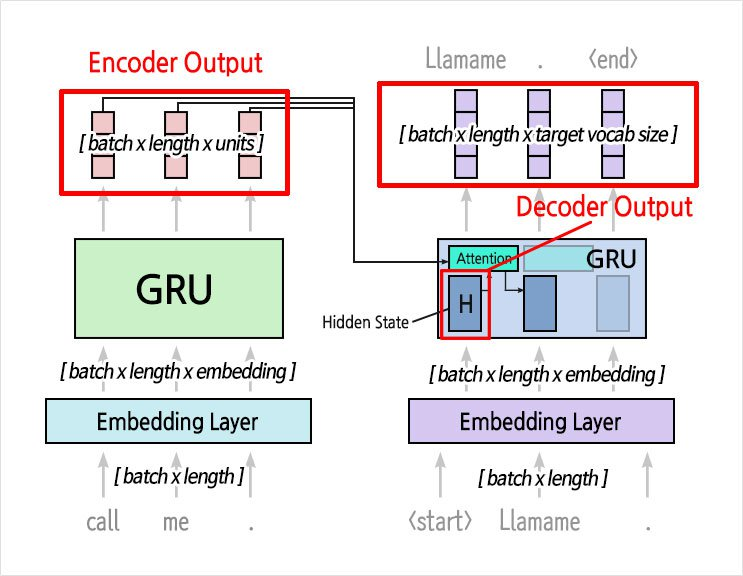

[GRU 구조]

Encoder는 **모든 Time-Step의 Hidden State를 출력**으로 갖고, Decoder는 **Encoder의 출력**과 Decoder의 **t-1 Step의 Hidden State로 Attention**을 계산하고, 그 컨텍스트 벡터를 현재 스텝의 출력(Hidden State)과 결합하여 **t Step의 예측**을 만들어 냅니다.

Decoder에서 t Step의 단어로 예측된 것을 실제 정답과 대조해 Loss를 구하고, 생성된 t Step의 Hidden State는 t+1 Step의 Hidden State를 만들기 위해 다시 Decoder에 전달됩니다.

여기서 '**t=1 일 때의 Hidden State는 어떻게 정의할 것인가?**' 가 궁금하실 수 있는데요, 일반적으로 Encoder의 Final State를 Hidden State로 사용합니다.

Attention은 Bahdanau을 사용할 예정이며, 이는 이전 렉처 노드에서 실습한 코드를 가져다가 쓰도록 할게요.

**Q. Bahdanau Attention을 사용할 예정인데 특징이 뭐였죠?**

<details>
<summary>💡예시답안 확인하기💡</summary>

입력 시퀀스의 각 위치마다 가중치를 학습하여 중요도를 결정합니다. \
즉, 입력 시퀀스의 다른 위치에 대한 주의도가 다를 수 있습니다. 이를 통해 모델이 입력 시퀀스의 특정 부분에 집중하거나 무시할 수 있습니다.
</details>

In [19]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

**위 그림과 동일한 구조를 갖는 `Encoder` 클래스와 `Decoder` 클래스를 설계하고, 아래 소스를 실행해 답안과 같은 결과를 얻으세요.**

In [20]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

In [21]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [22]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
            # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [24]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [25]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)


코드를 실행하면 다음과 같은 형식의 결과가 나와야 합니다.

```bash
Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)
```

<details>
<summary>Encoder 예제 코드</summary>


```python
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden
```

</details>


<details>
<summary>Decoder 예제 코드</summary>

```python
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)

        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)
```

</details>

# 훈련하기 (1) Optimizer & Loss
지금까지는 Optimizer 안에 파라미터를 간편하게 입력했지만, Encoder-Decoder 구조의 경우 모델이 분리되어 파라미터를 각각 정의해줘야 합니다. 조금 불편하고 난감하게 다가올 수도 있지만 후에 더 멋진 연구를 하기 위한 발판이 되어 줄 테니 익숙해져 봅시다!

낯선 함수들이 지나치게 많이 등장할 수 있으니, 이번 코스에선 직접 구현을 하기보단 구현체를 먼저 보고 이해하는 방향으로 공부하도록 합시다!

## Optimizer & Loss
---
가장 큰 줄기를 먼저 보고, 점점 더 들어가 보는 방식으로 진행해볼게요. 첫 순서는 **Optimizer와 Loss**입니다!

In [26]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")

슝~


**Optimizer**는 모델이 학습할 때에 정답을 찾아가는 방법 정도로 설명할 수 있는데, 일반적으론 Adam 외의 것을 사용하지 않으니 후에 실력이 더 늘어나고 나서 공부하시는 것을 권장합니다! 우선은 다른 배워야 할 것들이 산더미니까요...😅

`nn.CrossEntropyLoss()` 함수는 **모델이 출력한 확률 분포**와 (One-hot이 아닌) **정수 인덱스 답안**을 비교해 Cross Entropy값을 구해줍니다. `nn.NLLLoss()`라면 `[ 0.1, 0.2, 0.7 ]` 과 One-hot 인코딩된 라벨 `[0, 0, 1]` 을 비교하여 점수를 채점하겠지만, `nn.CrossEntropyLoss()` 함수라면 `[ 0.1, 0.2, 0.7 ]` 과 정수 인덱스 답안 `2` 를 비교하여 점수를 채점하는 거죠.

**Q. 패딩(Padding) 과정을 진행하는 이유가 뭘까요?**

<details>
<summary>💡예시답안 확인하기💡</summary>

효율적인 배치 처리, 메모리 효율성 등이 있습니다.
</details>

만약 모델에게 `<PAD>` 토큰이 **패딩을 위한 토큰이라고 명시하지 않으면** 모델은 데이터의 굉장히 많은 부분이 `<PAD>` 로 이뤄져 있다고 생각하게 됩니다. 쉽게 말해 **유난히 같은 답이 많은 객관식 시험**이라고나 할까요...? 어떤 시험이 한 번호로만 찍어도 80점 이상을 받을 수 있다면 그 시험은 공부를 절대 하지 않겠죠! 모델은 심지어 10,000개의 정답이 넘게 있는 고난도의 문제를 풀고 있기 때문에 **패딩에 대한 처리**를 해주지 않으면 `<PAD>` **토큰만을 생성할 확률이 굉장히 높아집니다.**

이것은 종종 발생하는 문제라서 기억해두시면 좋아요. 이 문제를 방지하기 위해 `mask` 가 사용됩니다! `mask` 는 정답지에서 `<PAD>` 토큰을 찾아내어 그 부분에 대한 Loss는 구하지 않도록 하는 역할을 해주죠. `equal()` 함수에 정확히는 0 이 아닌 `<PAD>` 토큰의 인덱스를 전달하는 것이 맞지만 **대부분의 경우는 0으로 패딩되기 때문에 편의상 0을 전달**하여 처리하도록 하겠습니다.

# 훈련하기 (2) train_step 구현하기
`train_step()`은 학습에 필요한 것을 모두 가져가 **Loss를 계산한 후 반환하는 함수**입니다. 먼저 구성을 보시죠!

In [27]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        src, trg_input, trg_label = src.to(device), trg_input.to(device), trg_label.to(device)

        # DataLoader는 (batch, seq_len) 배치를 주지만, 모델/Encoder/Decoder는 (seq_len, batch)를 기대합니다.
        # 전치하지 않으면 batch와 seq_len 축이 뒤바뀌어 (오류 없이) 잘못된 정렬로 학습됩니다.
        src = src.transpose(0, 1)
        trg_input = trg_input.transpose(0, 1)
        trg_label = trg_label.transpose(0, 1)

        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)

        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")


슝~


코드를 좀 더 자세히 살펴봅시다.

`train_step()`의 학습 과정은 아래와 같습니다.

1. model.train()을 호출하여 모델을 학습 모드로 전환합니다.
2. optimizer.zero_grad()를 통해 이전 배치에서 계산된 기울기를 초기화합니다.
3. Encoder에 소스 문장을 전달해 **컨텍스트 벡터인 `enc_out` 을 생성**
4. **t=0일 때**, Decoder의 Hidden State는 **Encoder의 Final State로 정의**. `h_dec = enc_hidden`
Encoder 처리
5. `<start>` 문장과 enc_out, Hidden State를 기반으로 **다음 단어(t=1)를 예측**. `predictions`
6. 예측된 단어와 정답 간의 Loss를 구한 후, t=1의 **정답 단어를 다음 입력으로 사용** (예측 단어 사용X)
7. 반복!

코드를 한 줄 한 줄 살피면 이해가 어려운 라인은 없을 거예요.

# 훈련하기 (3) 훈련 시작하기
다음 순서는 본격적으로 **훈련을 시작하는 부분**입니다! (훈련 시간은 약 15분 정도 소요 됩니다.)

In [28]:
%%time

EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 1: 100%|██████████| 1488/1488 [02:40<00:00,  9.29it/s, loss=1.62]


Epoch 1/10, Train Loss: 2.6346


Epoch 2: 100%|██████████| 1488/1488 [02:40<00:00,  9.25it/s, loss=1.01]


Epoch 2/10, Train Loss: 1.4320


Epoch 3: 100%|██████████| 1488/1488 [02:41<00:00,  9.21it/s, loss=0.974]


...

Epoch 8/10, Train Loss: 0.3828


Epoch 9: 100%|██████████| 1488/1488 [02:40<00:00,  9.28it/s, loss=0.266]


Epoch 9/10, Train Loss: 0.3432


Epoch 10: 100%|██████████| 1488/1488 [02:40<00:00,  9.27it/s, loss=0.347]

Epoch 10/10, Train Loss: 0.3209
CPU times: user 26min 16s, sys: 8.36 s, total: 26min 24s
Wall time: 26min 48s


먼저 `tqdm`은 훈련의 진행 과정을 한눈에 볼 수 있게 해주는 라이브러리입니다. 사용법은 위 예제만 봐도 이해가 갈 정도로 정말 간단하니 웬만하면 활용하시는 것을 추천해 드려요! `# tqdm`이 붙은 라인은 모두 출력에 관련된 내용이니 설명을 생략하겠습니다. 궁금하신 분들은 아래 github을 참고하시길 바라요!

- [tqdm/tqdm](https://github.com/tqdm/tqdm)

먼저 `EPOCHS = 10` 만큼 반복하는 루프에 진입한 후, 각 배치의 시작 인덱스를 `idx_list` 배열에 저장합니다. 그리고 모델이 학습을 원활하게 할 수 있도록 데이터를 섞어줘야 하는데요, **인덱스를 섞어서 처리**할 겁니다. 순차적인 인덱스로 데이터를 불러오는 게 아닌 랜덤한 인덱스로 데이터를 불러오는 것은 데이터를 섞는 것과 동일한 효과를 가져오겠죠!

그 후에 각 미니배치를 `train_step()` 함수에서 학습합니다. `train_step()`은 학습에 필요한 것은 모두 가져가 **Loss를 계산한 후 반환하는 함수**였죠!

이번 기회에 Encoder-Decoder 구조의 학습 방법을 마스터하세요! `optimizer`와 `loss`, `train_step()`까지 정의한 후 훈련을 시작하면 아래와 같은 결과를 확인할 수 있습니다.


```
Epoch 1: 100%|██████████| 375/375 [02:38<00:00,  2.37it/s, loss=1.54]
Epoch 1/10, Train Loss: 1.7942
Epoch 2: 100%|██████████| 375/375 [02:46<00:00,  2.25it/s, loss=1.4]
Epoch 2/10, Train Loss: 1.4438

...

Epoch 10: 100%|██████████| 375/375 [02:49<00:00,  2.21it/s, loss=1.27]
Epoch 10/10, Train Loss: 1.2092

```


## 실습하기
---
이제 직접 실습해 볼까요?

**Step 1에서 분리한 Validation Set을 사용하는 `eval_step()` 함수를 정의하세요! 그리고 train_step() 을 마친 후, 곧이어 `eval_step()` 을 진행하도록 소스를 수정하세요! 결과는 아래와 같은 형태가 되어야 합니다.**

(주의! Evaluation 중에는 모델이 학습을 해서는 안 됩니다!)


```bash
Epoch  1: 100%|██████████| 375/375 [00:50<00:00,  7.45it/s, Loss 1.7839]
Test Epoch  1: 100%|██████████| 94/94 [00:09<00:00,  9.75it/s, Test Loss 1.4220]
Epoch  2: 100%|██████████| 375/375 [00:31<00:00, 11.74it/s, Loss 1.2333]
Test Epoch  2: 100%|██████████| 94/94 [00:02<00:00, 46.58it/s, Test Loss 1.1305]
Epoch  3: 100%|██████████| 375/375 [00:31<00:00, 11.77it/s, Loss 0.9801]
Test Epoch  3: 100%|██████████| 94/94 [00:01<00:00, 48.42it/s, Test Loss 0.9771]
Epoch  4: 100%|██████████| 375/375 [00:31<00:00, 11.74it/s, Loss 0.7998]
Test Epoch  4: 100%|██████████| 94/94 [00:02<00:00, 46.70it/s, Test Loss 0.8701]
Epoch  5: 100%|██████████| 375/375 [00:31<00:00, 11.81it/s, Loss 0.6553]
Test Epoch  5: 100%|██████████| 94/94 [00:01<00:00, 47.60it/s, Test Loss 0.7903]
...
```



In [29]:
def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    # 평가 시에는 기울기 계산을 하지 않도록 설정합니다.
    with torch.no_grad():
        for src, trg_input, trg_label in data_loader:
            src, trg_input, trg_label = src.to(device), trg_input.to(device), trg_label.to(device)

            # 학습과 동일하게 (seq_len, batch)로 전치
            src = src.transpose(0, 1)
            trg_input = trg_input.transpose(0, 1)
            trg_label = trg_label.transpose(0, 1)

            outputs, _ = model(src, trg_input)

            # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
            outputs = outputs.reshape(-1, outputs.shape[-1])
            trg_label = trg_label.reshape(-1)

            loss = criterion(outputs, trg_label)

            total_loss += loss.item()

    return total_loss / len(data_loader)

print("슝~")

슝~


In [30]:
%%time

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Epoch 1: 100%|██████████| 1488/1488 [02:40<00:00,  9.29it/s, loss=0.334]


Epoch 1/20, Train Loss: 0.3034, Validation Loss: 1.8925


Epoch 2: 100%|██████████| 1488/1488 [02:40<00:00,  9.25it/s, loss=0.273]


Epoch 2/20, Train Loss: 0.2895, Validation Loss: 1.9443


Epoch 3: 100%|██████████| 1488/1488 [02:39<00:00,  9.31it/s, loss=0.209]


...

Epoch 18/20, Train Loss: 0.2850, Validation Loss: 2.4439


Epoch 19: 100%|██████████| 1488/1488 [02:39<00:00,  9.30it/s, loss=0.293]


Epoch 19/20, Train Loss: 0.2895, Validation Loss: 2.4527


Epoch 20: 100%|██████████| 1488/1488 [02:40<00:00,  9.29it/s, loss=0.242]


Epoch 20/20, Train Loss: 0.2930, Validation Loss: 2.4699
CPU times: user 57min 11s, sys: 16.2 s, total: 57min 27s
Wall time: 58min 13s


훈련이 완료된 모델은 아래 소스를 실행해 번역 성능을 평가할 수 있어요. Attention Map을 시각화하는 것은 보너스!

In [31]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30, eos_id=2):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    pred_ids = outputs.argmax(2).squeeze(1).tolist()

    # SentencePiece는 EOS를 빈 문자열로 디코딩하므로 "<end>" 문자열 비교로는 잘리지 않습니다.
    # 토큰 id 기준(eos_id)으로 잘라줍니다.
    if eos_id in pred_ids:
        pred_ids = pred_ids[:pred_ids.index(eos_id)]

    # Attention 시각화의 y축 라벨로 쓰기 위해 토큰(subword) 단위 조각으로 반환
    result = [decoder_tokenizer.id_to_piece(i) for i in pred_ids]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [32]:
import matplotlib.font_manager as fm

# 한글 폰트 명시적 설정
fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=14)

def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontproperties=fontprop, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontproperties=fontprop)

    plt.show()

In [33]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

Input: the most powerful man all over the world .
Predicted translation: ['▁el', '▁más', '▁sa', 'b', 'r', 'oso', '▁es', '▁igual', '▁al', '▁mundo', '▁todo', '▁el', '▁mundo', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 225 (\N{LATIN SMALL LETTER A WITH ACUTE}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


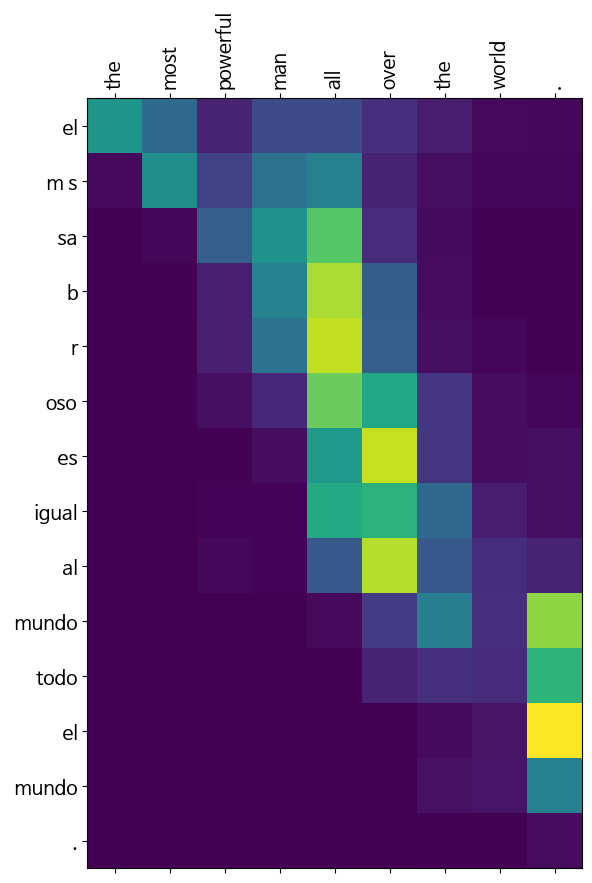

In [34]:
translate("The most powerful man all over the world.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: may i help you ?
Predicted translation: ['▁puedo', '▁ayudar', 'le', '▁?']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


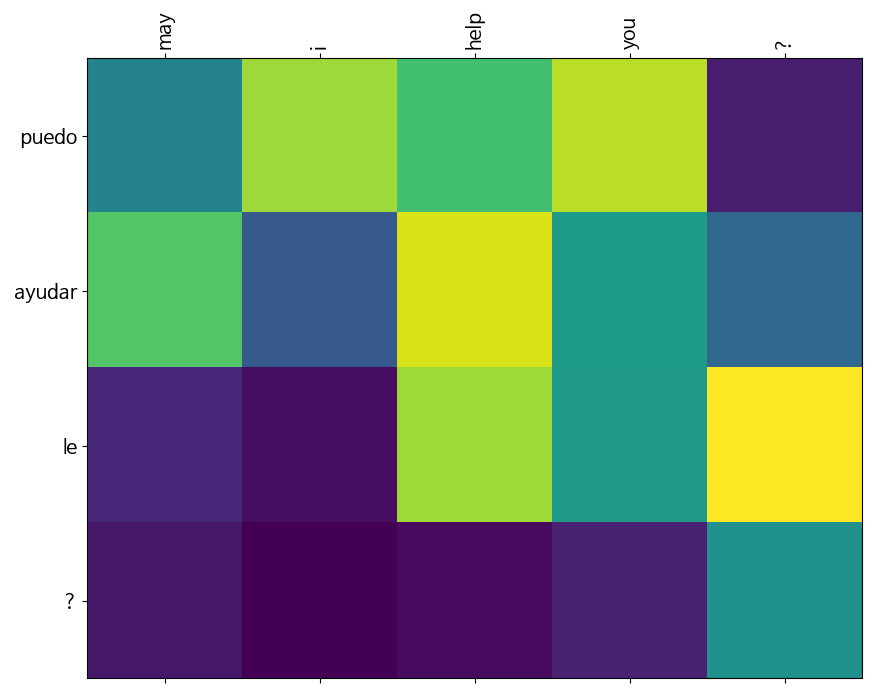

In [35]:
translate("May I help you?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: can i have some coffee ?
Predicted translation: ['▁me', '▁puede', '▁alguno', '▁de', '▁café', '▁?']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 233 (\N{LATIN SMALL LETTER E WITH ACUTE}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


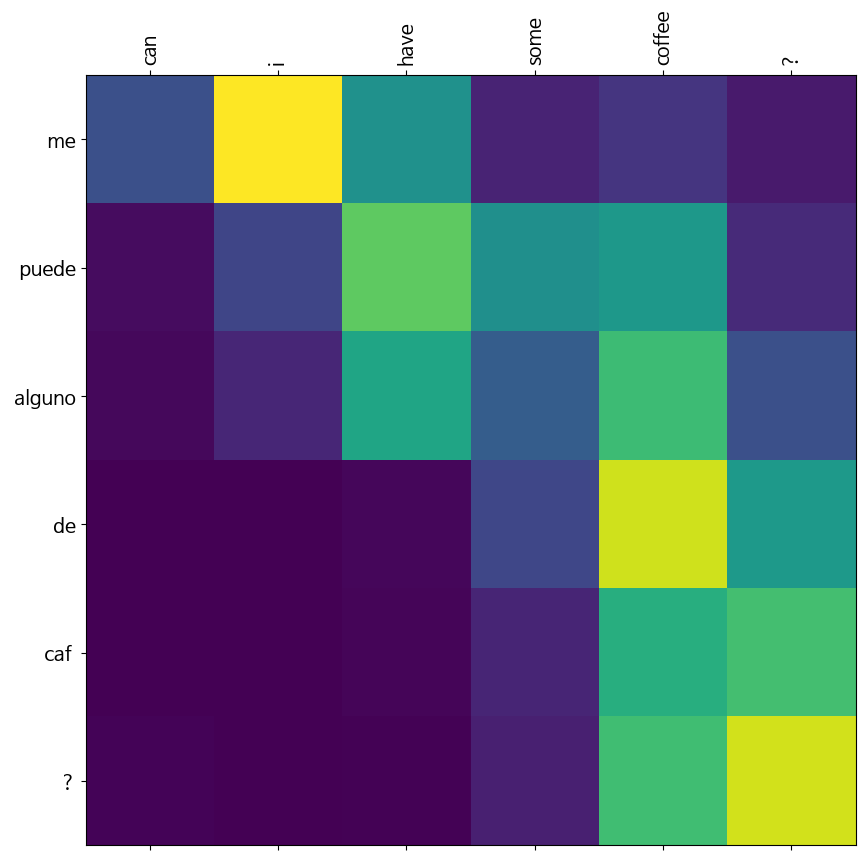

In [36]:
# 실행 예제
translate("Can I have some coffee?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

### 모델 번역 결과 vs 실제 정답 비교해보기

In [37]:
import random

# 검증 데이터셋에서 무작위로 5개의 샘플을 추출합니다.
samples = valid_data.sample(5)

print("=== 번역 결과 vs 실제 문장 비교 ===\n")

for idx, row in samples.iterrows():
    eng_text = row['eng']
    spa_text = row['spa']

    # 모델을 통해 번역 예측 (evaluate 함수 사용)
    result, _, _ = evaluate(eng_text, model, encoder_tokenizer, decoder_tokenizer, max_len=30)

    # SentencePiece의 띄어쓰기 특수기호( )를 일반 공백으로 변환하여 문장 복원
    pred_sentence = "".join(result).replace(' ', ' ').strip()

    print(f"🗣️ 영어 (Input)    : {eng_text}")
    print(f"✅ 실제 (Actual)   : {spa_text}")
    print(f"🤖 예측 (Predicted): {pred_sentence}")
    print("-" * 60)

=== 번역 결과 vs 실제 문장 비교 ===

🗣️ 영어 (Input)    : she didn t want him to play poker .
✅ 실제 (Actual)   : ella no quería que él jugara póquer .
🤖 예측 (Predicted): ▁ella▁no▁quiso▁que▁él▁se▁jugara▁pó<unk>er▁.
------------------------------------------------------------
🗣️ 영어 (Input)    : she is not honest at all .
✅ 실제 (Actual)   : no es honesta del todo .
🤖 예측 (Predicted): ▁no▁es▁nada▁honesto▁.
------------------------------------------------------------
🗣️ 영어 (Input)    : i was looking at old pictures .
✅ 실제 (Actual)   : estaba viendo fotografías viejas .
🤖 예측 (Predicted): ▁estuve▁mirando▁ese▁viejo▁toda▁fotografía▁.
------------------------------------------------------------
🗣️ 영어 (Input)    : tom asked mary to scrub the toilet .
✅ 실제 (Actual)   : tom le pidió a mary que refregara el retrete .
🤖 예측 (Predicted): ▁tom▁le▁pidió▁a▁mary▁que▁es▁un▁recidencia▁del▁alza▁.
------------------------------------------------------------
🗣️ 영어 (Input)    : i was just thinking of a new job .
✅ 실제 (Actual)  

아래와 같은 맵이 나오면 성공입니다.

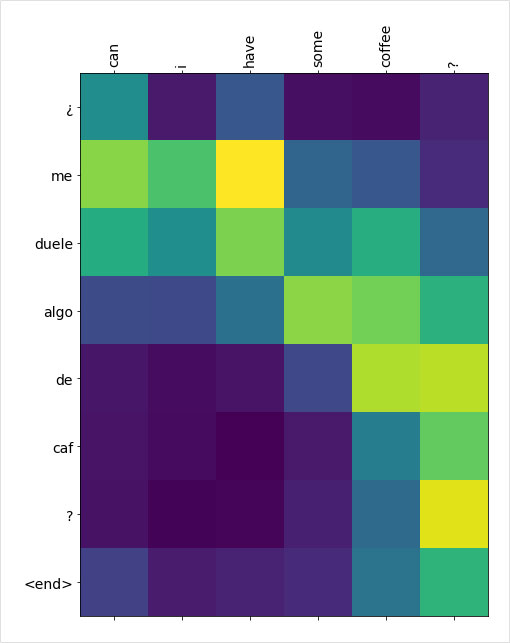

<details><summary>eval_step 예시 코드</summary>


```python
# Define eval_step

def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        src, trg_input, trg_label = src.to(device), trg_input.to(device), trg_label.to(device)

        # 학습과 동일하게 (seq_len, batch)로 전치
        src = src.transpose(0, 1)
        trg_input = trg_input.transpose(0, 1)
        trg_label = trg_label.transpose(0, 1)

        outputs, _ = model(src, trg_input)

        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

    return total_loss / len(data_loader)

print("슝~")


# Training Process

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')
```
</details>

---
# [프로젝트] 한국어-영어 번역기 만들기

지금부터는 루브릭 평가 기준을 만족하기 위한 **한국어-영어 번역기 프로젝트**를 진행합니다. 제공된 뉴스 병렬 말뭉치 데이터를 다운로드하고 전처리해보겠습니다.

In [38]:
import os
import urllib.request
import tarfile
import pandas as pd

# 다운로드 경로 설정
project_dir = "/content/ko-en-project"
os.makedirs(project_dir, exist_ok=True)
tar_path = os.path.join(project_dir, "korean-english-park.train.tar.gz")

# 1. 데이터 다운로드
url = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz"
if not os.path.exists(tar_path):
    print("데이터 다운로드 중...")
    urllib.request.urlretrieve(url, tar_path)
    print("다운로드 완료!")
else:
    print("이미 데이터가 존재합니다.")

# 2. 압축 해제
print("압축 해제 중...")
with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall(path=project_dir)
print("압축 해제 완료!")

# 3. 데이터 로드
ko_path = os.path.join(project_dir, "korean-english-park.train.ko")
en_path = os.path.join(project_dir, "korean-english-park.train.en")

with open(ko_path, "r", encoding="utf-8") as f:
    ko_data = f.read().splitlines()

with open(en_path, "r", encoding="utf-8") as f:
    en_data = f.read().splitlines()

# 데이터프레임으로 변환
project_df = pd.DataFrame({"ko": ko_data, "en": en_data})

print(f"\n총 데이터 개수: {len(project_df)}")
display(project_df.head())

데이터 다운로드 중...
다운로드 완료!
압축 해제 중...
압축 해제 완료!


/tmp/ipykernel_2049/1567787325.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=project_dir)



총 데이터 개수: 94123


,ko,en
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","Much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"Like all optical mice, But it also doesn't nee..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,Intelligence officials have revealed a spate o...


## Step 2. 데이터 정제 (Data Cleaning)
---
루브릭 요구사항에 맞춰 아래 순서로 데이터를 정제합니다.

1. `set` 자료형으로 (한국어, 영어) **병렬 쌍**의 중복을 제거 → `cleaned_corpus`
2. 한글을 지원하도록 `preprocessing()` 함수 재정의
3. 타겟 언어(영어)에는 `<start>`/`<end>` 토큰을 추가하고 `split()`으로 토큰화, 한국어는 KoNLPy `Mecab`으로 형태소 분석
4. 토큰 길이가 40 이하인 데이터만 선별하여 `eng_corpus`, `kor_corpus` 구축

In [39]:
# ko_data, en_data는 인덱스가 맞춰진 병렬 리스트입니다.
# 각 언어를 따로 set()에 넣으면 병렬 관계(같은 인덱스 = 같은 문장쌍)가 깨지므로,
# 반드시 (한국어, 영어) '쌍' 자체를 하나의 원소로 다뤄서 set에 넣어야 합니다.
print(f"중복 제거 전 데이터 쌍 개수: {len(ko_data)}")

paired = list(zip(ko_data, en_data))     # (한국어 문장, 영어 문장) 쌍 생성
cleaned_pairs = list(set(paired))        # set의 중복 불허 성질을 이용해 중복 쌍 제거

# 비어있거나 공백만 있는 문장쌍은 제거
cleaned_corpus = [(ko, en) for ko, en in cleaned_pairs if ko.strip() and en.strip()]

print(f"중복 제거 후 데이터 쌍 개수: {len(cleaned_corpus)}")
cleaned_corpus[:3]


중복 제거 전 데이터 쌍 개수: 94123
중복 제거 후 데이터 쌍 개수: 78968


[('유럽연합(EU)의 일부 회원국도 18일 코소보를 독립국가로 인정했다.',
  "European Union nations Monday were also starting to individually recognize Kosovo as the world's newest nation but had not agreed collectively on the way forward."),
 ('BBC는 80명의 시위대가 중국의 탄압으로 사망한 것으로 알려졌다고 보도했다.',
  'The BBC reports up to 80 protesters are reported to have died in the Chinese crackdown.'),
 ('더 가디언은 ‘반지의 제왕’은 볼거리가 많다며 뮤지컬 관람으로는 최상의 선택이라고 호평했다.',
  'It also praised the acting of Malcolm Storry as Gandalf, Brian Protheroe as Saruman and Andrew Jarvis as Elrond, "whose kingly voice resonates like thunder.')]

### 한글을 지원하는 `preprocessing()` 재정의

기존 실습에서 사용한 `preprocess_sentence()`는 스페인어 알파벳(`a-záéíóúüñ`)만 남기는 정규식을 사용하기 때문에, 이 함수를 그대로 한국어에 적용하면 한글이 전부 사라져 버립니다.
한글 유니코드 범위(완성형 `가-힣`, 자모 `ㄱ-ㅎ`, `ㅏ-ㅣ`)를 추가로 허용하도록 `preprocessing()`을 재정의합니다.

In [40]:
import re

def preprocessing(sentence, lang="en"):
    """
    lang="ko" : 한국어 문장 정제 (한글 유니코드 범위를 보존)
    lang="en" : 영어 문장 정제 (기존 스페인어 버전에서 알파벳만 남기도록 재정의)
    """
    sentence = sentence.strip()
    if lang == "en":
        sentence = sentence.lower()

    # 구두점(? . ! ,) 앞뒤에 공백을 넣어 하나의 토큰으로 분리되게 함
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    # 연속된 공백을 하나로 축소
    sentence = re.sub(r'[" "]+', " ", sentence)

    if lang == "ko":
        # 한글 완성형, 자모, 숫자, 지정 구두점 외의 문자는 공백으로 치환
        sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣ0-9?.!,]+", " ", sentence)
    else:
        # 영문 알파벳, 숫자, 지정 구두점 외의 문자는 공백으로 치환
        sentence = re.sub(r"[^a-z0-9?.!,]+", " ", sentence)

    sentence = sentence.strip()
    return sentence

print(preprocessing("오바마는 미국 대통령이다.", lang="ko"))
print(preprocessing("Obama is the President of the United States.", lang="en"))


오바마는 미국 대통령이다 .
obama is the president of the united states .


### KoNLPy Mecab 설치

한국어 형태소 분석을 위해 KoNLPy와 Mecab을 설치합니다. (설치는 몇 분 정도 소요될 수 있습니다.)

In [41]:
# KoNLPy 및 Mecab 설치 (설치 완료 후 다음 셀부터 진행하세요)
!pip install konlpy
!sudo apt-get install -y curl git
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)
!pip install mecab-python3


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 53.8 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 34.7 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
curl is already the newest version (7.81.0-1ubuntu1.26).
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 57 not upgraded.
Install mecab-ko
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1381k  100 1381k    0     0   906k      0  0:00:01  0:00:01 --:--:-- 1729k
mecab-0.996-ko-0.9.2/
mecab-0.996-ko-0.9.2/example/
mecab-0.996-ko-0.9.2/example/example.cpp
mecab-0.996-ko-0.9.2/example/example_lattice.cpp
mecab-0.996-ko-0.9.2/example/example_lattice.c
mecab-0.996-ko-0.9.2/example/ex

### 토큰화 함수 정의

- **한국어(source)**: KoNLPy `Mecab` 클래스의 `morphs()`로 형태소 단위 토큰화 (start/end 토큰 불필요)
- **영어(target)**: `<start>`, `<end>` 토큰을 문장 앞뒤에 붙인 뒤 `split()`으로 단어 단위 토큰화

In [42]:
from konlpy.tag import Mecab

mecab = Mecab()

START_TOKEN = "<start>"
END_TOKEN = "<end>"

def tokenize_ko(sentence):
    """한국어(source) 토큰화: 정제 + Mecab 형태소 분석"""
    cleaned = preprocessing(sentence, lang="ko")
    return mecab.morphs(cleaned)

def tokenize_en(sentence):
    """영어(target) 토큰화: 정제 + <start>/<end> 추가 + split()"""
    cleaned = preprocessing(sentence, lang="en")
    cleaned = f"{START_TOKEN} {cleaned} {END_TOKEN}"
    return cleaned.split()

print(tokenize_ko("오바마는 미국 대통령이다."))
print(tokenize_en("Obama is the President of the United States."))


['오바마', '는', '미국', '대통령', '이', '다', '.']
['<start>', 'obama', 'is', 'the', 'president', 'of', 'the', 'united', 'states', '.', '<end>']


### 길이 필터링: `eng_corpus`, `kor_corpus` 구축

`cleaned_corpus` 전체(수십만 쌍)를 그대로 사용하면 학습에 매우 오랜 시간이 걸립니다. 토큰 길이가 40 이하인 데이터만 선별해 `eng_corpus`, `kor_corpus`를 구축합니다.

계산 자원이 제한적인 경우를 대비해 `SAMPLE_SIZE`로 정제 후 데이터 중 일부만 사용할 수 있게 했습니다. 전체 데이터를 쓰고 싶다면 `SAMPLE_SIZE = None`으로 바꿔주세요.

In [43]:
import random
from tqdm import tqdm

MAX_TOKEN_LEN = 40
SAMPLE_SIZE = 30000  # 전체 cleaned_corpus를 쓰려면 None으로 변경

pairs_to_process = cleaned_corpus
if SAMPLE_SIZE is not None and len(pairs_to_process) > SAMPLE_SIZE:
    random.seed(42)
    pairs_to_process = random.sample(pairs_to_process, SAMPLE_SIZE)

eng_corpus = []
kor_corpus = []

for ko_sentence, en_sentence in tqdm(pairs_to_process, desc="토큰화 및 길이 필터링"):
    ko_tokens = tokenize_ko(ko_sentence)
    en_tokens = tokenize_en(en_sentence)

    if len(ko_tokens) == 0 or len(en_tokens) <= 2:  # <start> <end> 뿐인 빈 문장 제외
        continue

    # 토큰 길이가 40 이하인 데이터만 선별 (병렬 쌍 유지)
    if len(ko_tokens) <= MAX_TOKEN_LEN and len(en_tokens) <= MAX_TOKEN_LEN:
        kor_corpus.append(ko_tokens)
        eng_corpus.append(en_tokens)

print(f"필터링 후 데이터 개수: {len(kor_corpus)}쌍")
print("KO 샘플:", kor_corpus[0])
print("EN 샘플:", eng_corpus[0])


토큰화 및 길이 필터링: 100%|██████████| 30000/30000 [00:05<00:00, 5452.22it/s]

필터링 후 데이터 개수: 23307쌍
KO 샘플: ['제작', '팀', '은', '16', '일', '밤', '에', '올라간', '시청', '률', '을', '이용', '해', '위크', '엔드', '업데이트', '스페셜', '을', '추가', '편성', '했', '다', '.']
EN 샘플: ['<start>', 'snl', 'has', 'even', 'added', 'a', 'thursday', 'night', 'weekend', 'update', 'special', 'to', 'capitalize', 'on', 'the', 'increased', 'audience', '.', '<end>']


## Step 3. 데이터 토큰화
---
`tokenize()` 함수를 정의해 `kor_corpus`, `eng_corpus`를 각각 텐서로 변환하고, 각 언어의 `tokenizer`(단어 사전)를 얻습니다. 단어 수는 실험을 통해 조정하되 **최소 10,000 이상**으로 설정합니다.

❗ 주의: 데이터가 많지 않은 만큼(루브릭 안내에 따라) 훈련 데이터와 검증 데이터를 따로 나누지 않고 전체 데이터로 학습합니다.

In [44]:
import numpy as np
from collections import Counter

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

class Tokenizer:
    """SentencePieceProcessor와 유사한 인터페이스를 갖는 단어 단위(word-level) 토크나이저"""
    def __init__(self, word2idx):
        self.word2idx = word2idx
        self.idx2word = {i: w for w, i in word2idx.items()}

    def __len__(self):
        return len(self.word2idx)

    def encode(self, tokens):
        unk = self.word2idx[UNK_TOKEN]
        return [self.word2idx.get(t, unk) for t in tokens]

    def decode(self, ids):
        return [self.idx2word.get(i, UNK_TOKEN) for i in ids]

    def id_to_piece(self, idx):
        return self.idx2word.get(idx, UNK_TOKEN)

    def pad_id(self):
        return self.word2idx[PAD_TOKEN]

    def bos_id(self):
        return self.word2idx.get(START_TOKEN)

    def eos_id(self):
        return self.word2idx.get(END_TOKEN)


def tokenize(token_lists, vocab_size=10000, max_len=40):
    """
    token_lists : 이미 토큰화된 문장들의 리스트 (예: kor_corpus, eng_corpus)
    - 단어 빈도를 세어 vocab_size 크기의 단어 사전을 만들고
    - 각 문장을 정수 인덱스 시퀀스로 변환한 뒤 max_len 길이로 패딩한 텐서를 반환합니다.
    """
    counter = Counter()
    for tokens in token_lists:
        counter.update(tokens)

    specials = [PAD_TOKEN, UNK_TOKEN]
    most_common = [w for w, _ in counter.most_common(max(vocab_size - len(specials), 0))]
    word2idx = {w: i for i, w in enumerate(specials + most_common)}

    tokenizer = Tokenizer(word2idx)

    padded = np.zeros((len(token_lists), max_len), dtype=np.int64)
    for i, tokens in enumerate(token_lists):
        ids = tokenizer.encode(tokens)[:max_len]
        padded[i, :len(ids)] = ids

    tensor = torch.tensor(padded, dtype=torch.long)
    return tensor, tokenizer


VOCAB_SIZE = 12000  # 최소 10,000 이상, 실험을 통해 조정 가능
MAX_LEN = 40

kor_tensor, ko_tokenizer = tokenize(kor_corpus, vocab_size=VOCAB_SIZE, max_len=MAX_LEN)
eng_tensor, en_tokenizer = tokenize(eng_corpus, vocab_size=VOCAB_SIZE, max_len=MAX_LEN)

print(f"한국어 단어 사전 크기: {len(ko_tokenizer)}")
print(f"영어 단어 사전 크기: {len(en_tokenizer)}")
print(f"한국어 텐서 shape: {kor_tensor.shape}")
print(f"영어 텐서 shape: {eng_tensor.shape}")


한국어 단어 사전 크기: 12000
영어 단어 사전 크기: 12000
한국어 텐서 shape: torch.Size([23307, 40])
영어 텐서 shape: torch.Size([23307, 40])


In [45]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64

# eng_tensor에는 이미 <start> ... <end> ... <pad> 형태로 토큰이 들어 있으므로,
# 한 칸씩 shift하여 Decoder 입력(trg_input)과 라벨(trg_label)로 사용합니다.
trg_input_tensor = eng_tensor[:, :-1]
trg_label_tensor = eng_tensor[:, 1:]

ko_en_train_dataset = TensorDataset(kor_tensor, trg_input_tensor, trg_label_tensor)
ko_en_train_loader = DataLoader(ko_en_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"학습 데이터 개수: {len(ko_en_train_dataset)}")
for src, trg_input, trg_label in ko_en_train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break


학습 데이터 개수: 23307
torch.Size([64, 40]) torch.Size([64, 39]) torch.Size([64, 39])


## Step 4. 모델 설계
---
앞서 정의한 `Encoder`, `BahdanauAttention`, `Decoder`, `Seq2SeqAttention` 클래스를 그대로 재사용해 한국어→영어 번역 모델을 구성합니다. `Embedding Size`, `Hidden Size`는 실험을 통해 적당한 값으로 조정하세요.

In [46]:
EMB_DIM = 256  # 실험을 통해 조정 가능
HID_DIM = 512  # 실험을 통해 조정 가능

ko_en_encoder = Encoder(len(ko_tokenizer), EMB_DIM, HID_DIM).to(device)
ko_en_attention = BahdanauAttention(HID_DIM).to(device)
ko_en_decoder = Decoder(len(en_tokenizer), EMB_DIM, HID_DIM, ko_en_attention).to(device)
ko_en_model = Seq2SeqAttention(ko_en_encoder, ko_en_decoder, device).to(device)

print(ko_en_model)


Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(12000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(12000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=12000, bias=True)
  )
)


## Step 5. 훈련하기
---
훈련에는 위에서 정의한 `train_step()`을 그대로 사용합니다. **`eval_step()`은 사용하지 않습니다.** 대신 매 epoch마다 예문에 대한 번역을 생성해 학습 진행 상황을 확인합니다. (Attention Map 시각화는 마지막에 보너스로 확인합니다.)

In [47]:
ko_en_optimizer = optim.Adam(ko_en_model.parameters(), lr=1e-3)
ko_en_criterion = nn.CrossEntropyLoss(ignore_index=en_tokenizer.pad_id())

print("슝~")


슝~


In [48]:
def _translate_tokens(src_tokens, model, src_tokenizer, trg_tokenizer, max_len=40):
    """이미 토큰화된 한국어 토큰 리스트를 입력받아 번역 결과와 attention을 반환"""
    model.eval()

    src_ids = src_tokenizer.encode(src_tokens)[:max_len]
    src_ids = src_ids + [src_tokenizer.pad_id()] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    bos_id = trg_tokenizer.bos_id()
    eos_id = trg_tokenizer.eos_id()

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len, bos_id=bos_id, eos_id=eos_id)

    pred_ids = outputs.argmax(2).squeeze(1).tolist()
    if eos_id in pred_ids:
        pred_ids = pred_ids[:pred_ids.index(eos_id)]

    result = trg_tokenizer.decode(pred_ids)
    return result, attentions.squeeze(1).cpu().numpy()


def ko_en_evaluate(sentence, model, src_tokenizer, trg_tokenizer, max_len=40):
    """원문(문자열)을 입력받아 전처리 + Mecab 토큰화 후 번역"""
    src_tokens = tokenize_ko(sentence)
    result, attention = _translate_tokens(src_tokens, model, src_tokenizer, trg_tokenizer, max_len)
    return result, src_tokens, attention


def ko_en_translate(sentence, model, src_tokenizer, trg_tokenizer, max_len=40, plot=True):
    result, src_tokens, attention = ko_en_evaluate(sentence, model, src_tokenizer, trg_tokenizer, max_len)

    print('Input:', sentence)
    print('Predicted translation:', ' '.join(result))

    if plot:
        attn = attention[:len(result), :len(src_tokens)]
        plot_attention(attn, src_tokens, result)

    return ' '.join(result)

print("슝~")


슝~


In [49]:
# 학습 진행 상황을 모니터링할 예문
test_sentences = [
    "오바마는 미국 대통령이다.",
    "커피 한 잔 주세요.",
    "오늘 날씨가 정말 좋다.",
    "그는 매일 아침 신문을 읽는다.",
]


In [50]:
%%time

EPOCHS = 10  # 데이터/자원 상황에 맞게 조정

train_history = []

for epoch in range(EPOCHS):
    train_loss = train_step(ko_en_model, ko_en_train_loader, ko_en_optimizer, ko_en_criterion, epoch)
    train_history.append(train_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}")

    # 매 epoch마다 예문 번역 결과를 출력해 학습 진행 상황을 확인합니다. (eval_step 없이 진행)
    print("--- 예문 번역 확인 ---")
    for sentence in test_sentences:
        ko_en_translate(sentence, ko_en_model, ko_tokenizer, en_tokenizer, max_len=MAX_LEN, plot=False)
    print()


Epoch 1: 100%|██████████| 365/365 [01:21<00:00,  4.46it/s, loss=4.98]


Epoch 1/10, Train Loss: 5.6627
--- 예문 번역 확인 ---
Input: 오바마는 미국 대통령이다.
Predicted translation: obama is not a <unk> of the president .
Input: 커피 한 잔 주세요.
Predicted translation: the ap s office is a <unk> .
Input: 오늘 날씨가 정말 좋다.
Predicted translation: the ap s aaron heller is a <unk> .
Input: 그는 매일 아침 신문을 읽는다.
Predicted translation: he was the first time for the first time .



Epoch 2: 100%|██████████| 365/365 [01:21<00:00,  4.48it/s, loss=4.48]


Epoch 2/10, Train Loss: 4.5566
--- 예문 번역 확인 ---
Input: 오바마는 미국 대통령이다.
Predicted translation: obama is not going to be president .
Input: 커피 한 잔 주세요.
Predicted translation: a day of the <unk> , a <unk> and a <unk>
Input: 오늘 날씨가 정말 좋다.
Predicted translation: the new york times reports the dow is down the first time .
Input: 그는 매일 아침 신문을 읽는다.
Predicted translation: he is now down the <unk> .



Epoch 3: 100%|██████████| 365/365 [01:21<00:00,  4.48it/s, loss=3.85]


...

Epoch 8/10, Train Loss: 1.1217
--- 예문 번역 확인 ---
Input: 오바마는 미국 대통령이다.
Predicted translation: obama is being sent to the obama .
Input: 커피 한 잔 주세요.
Predicted translation: a lot of people joining you play there
Input: 오늘 날씨가 정말 좋다.
Predicted translation: today , the weather is good news for the field .
Input: 그는 매일 아침 신문을 읽는다.
Predicted translation: he was a <unk> .



Epoch 9: 100%|██████████| 365/365 [01:21<00:00,  4.47it/s, loss=1.25] 


Epoch 9/10, Train Loss: 0.8641
--- 예문 번역 확인 ---
Input: 오바마는 미국 대통령이다.
Predicted translation: obama is now headed
Input: 커피 한 잔 주세요.
Predicted translation: joining <unk> <unk> , one of the most famous dog .
Input: 오늘 날씨가 정말 좋다.
Predicted translation: this is a good day .
Input: 그는 매일 아침 신문을 읽는다.
Predicted translation: it was a wall street from the newspaper .



Epoch 10: 100%|██████████| 365/365 [01:21<00:00,  4.47it/s, loss=0.809]

Epoch 10/10, Train Loss: 0.6590
--- 예문 번역 확인 ---
Input: 오바마는 미국 대통령이다.
Predicted translation: obama is now the president .
Input: 커피 한 잔 주세요.
Predicted translation: you can t get to <unk> on <unk> .
Input: 오늘 날씨가 정말 좋다.
Predicted translation: this is a good weather .
Input: 그는 매일 아침 신문을 읽는다.
Predicted translation: he may be a wall street .

CPU times: user 12min 49s, sys: 37.8 s, total: 13min 27s
Wall time: 13min 35s


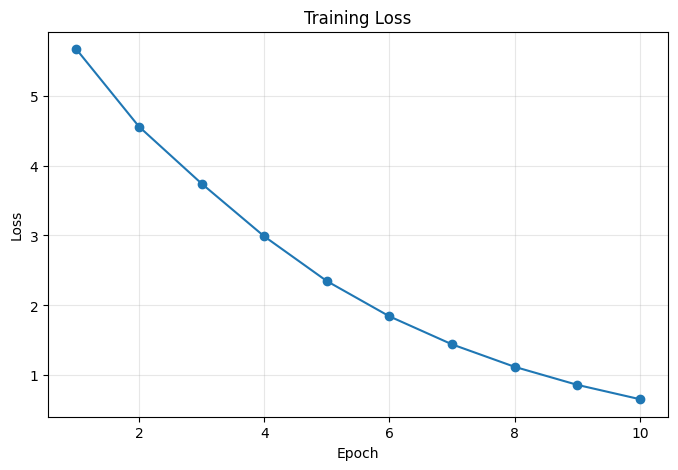

In [51]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_history) + 1), train_history, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()


## 최종 결과 확인
---
학습이 끝난 모델로 예문 번역 및 Attention Map을 확인합니다(보너스). 이 중 **본인이 생각하기에 가장 멋지게 번역한 case를 제출**하세요. 이어서 학습 데이터 중 일부를 무작위로 뽑아 실제 정답과 예측을 비교합니다.

=== 최종 번역 결과 및 Attention Map ===

Input: 오바마는 미국 대통령이다.
Predicted translation: obama is now the president .


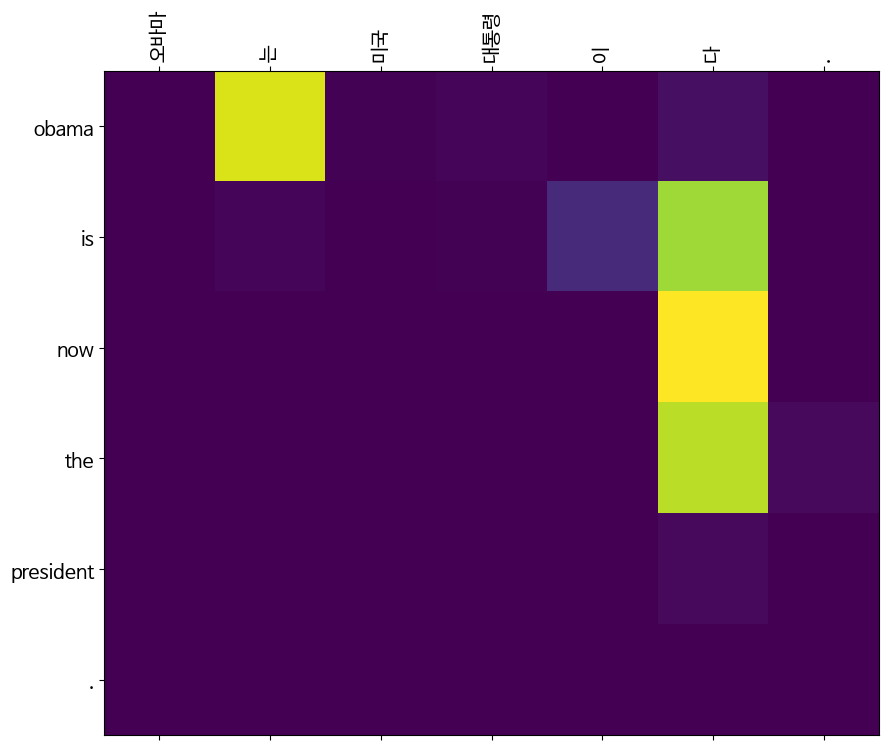

------------------------------------------------------------
Input: 커피 한 잔 주세요.
Predicted translation: you can t get to <unk> on <unk> .


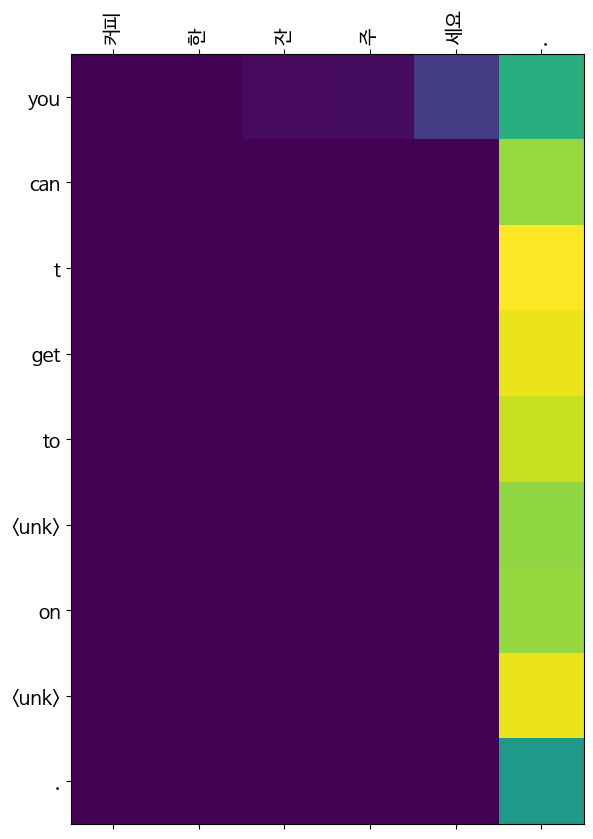

------------------------------------------------------------
Input: 오늘 날씨가 정말 좋다.
Predicted translation: this is a good weather .


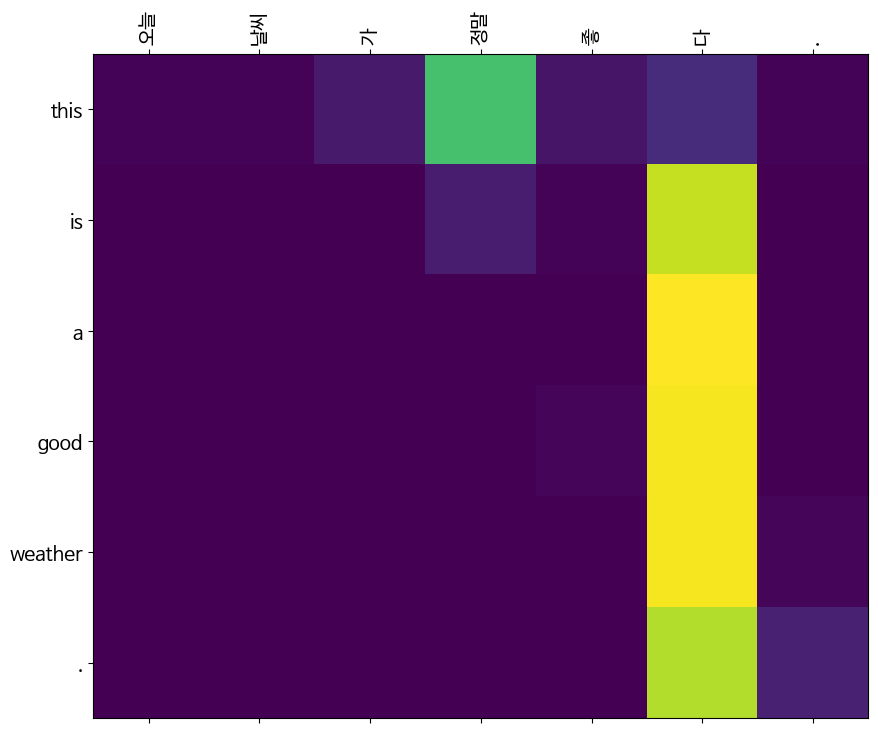

------------------------------------------------------------
Input: 그는 매일 아침 신문을 읽는다.
Predicted translation: he may be a wall street .


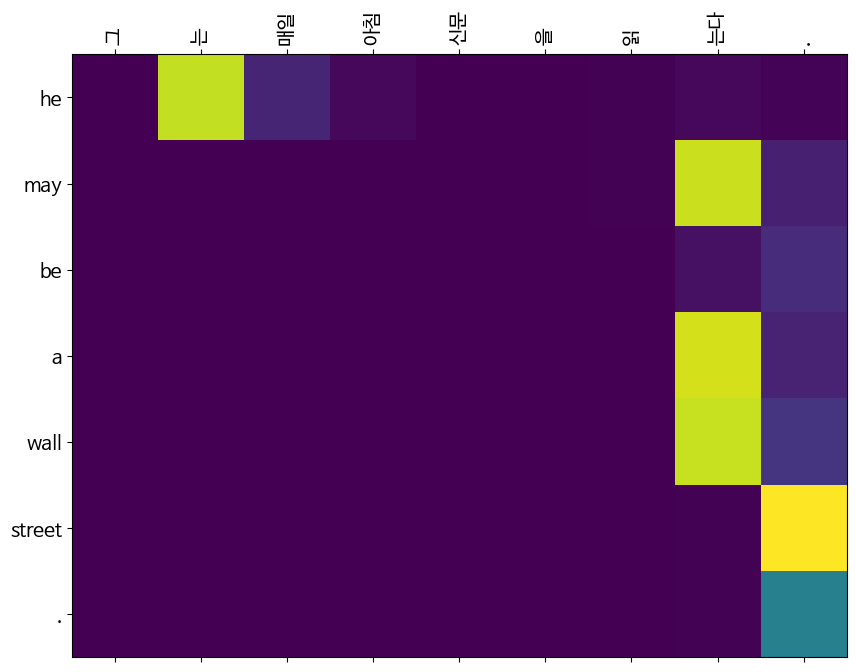

------------------------------------------------------------


In [52]:
print("=== 최종 번역 결과 및 Attention Map ===\n")

for sentence in test_sentences:
    ko_en_translate(sentence, ko_en_model, ko_tokenizer, en_tokenizer, max_len=MAX_LEN, plot=True)
    print("-" * 60)


In [53]:
print("=== 학습 데이터 중 무작위 샘플 번역 비교 ===\n")

random.seed(0)
sample_indices = random.sample(range(len(kor_corpus)), 5)

for idx in sample_indices:
    ko_tokens = kor_corpus[idx]
    en_tokens = eng_corpus[idx]

    ko_sentence = " ".join(ko_tokens)
    en_answer = " ".join(t for t in en_tokens if t not in (START_TOKEN, END_TOKEN))

    pred_tokens, _ = _translate_tokens(ko_tokens, ko_en_model, ko_tokenizer, en_tokenizer, max_len=MAX_LEN)
    pred_sentence = " ".join(pred_tokens)

    print(f"🗣️ 한국어 (Input)   : {ko_sentence}")
    print(f"✅ 실제 (Actual)    : {en_answer}")
    print(f"🤖 예측 (Predicted) : {pred_sentence}")
    print("-" * 60)


=== 학습 데이터 중 무작위 샘플 번역 비교 ===

🗣️ 한국어 (Input)   : 살람 파야드 팔레스타인 자치 정부 총리 는 원조금 이 마련 된 것 에 대하 여 원조금 모금 은 국제 사회 가 팔레스타인 을 신뢰 하 고 있 음 을 보여 주 고 있 다 고 주장 했 다 .
✅ 실제 (Actual)    : palestinian prime minister salam fayyad called the pledge of money a vote of confidence in the palestinians .
🤖 예측 (Predicted) : palestinian prime minister salam fayyad called the pledge of money a vote .
------------------------------------------------------------
🗣️ 한국어 (Input)   : 일본 국영 는 이번 지진 으로 2 명 이 경상 을 입 었 다고 보도 했 다 .
✅ 실제 (Actual)    : two people suffered minor injuries from falling furniture , public television broadcaster nhk reported .
🤖 예측 (Predicted) : two people suffered minor injuries from falling furniture , public television broadcaster broadcaster reported .
------------------------------------------------------------
🗣️ 한국어 (Input)   : 수사관 들 은 할아버지 가 멕시코 마약 거래 상 들 과 연루 되 었 기 때문 에 소년 이 유괴 되 었 을 가능 성 이 있 다고 전했 습니다 .
✅ 실제 (Actual)    : investigators say the boy may have been snatched because of his